In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.linear_model import LogisticRegression


# Simple EDA

        RI     Na    Mg    Al     Si     K    Ca   Ba   Fe  Type
0  1.52101  13.64  4.49  1.10  71.78  0.06  8.75  0.0  0.0     1
1  1.51761  13.89  3.60  1.36  72.73  0.48  7.83  0.0  0.0     1
2  1.51618  13.53  3.55  1.54  72.99  0.39  7.78  0.0  0.0     1
3  1.51766  13.21  3.69  1.29  72.61  0.57  8.22  0.0  0.0     1
4  1.51742  13.27  3.62  1.24  73.08  0.55  8.07  0.0  0.0     1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB
None
     

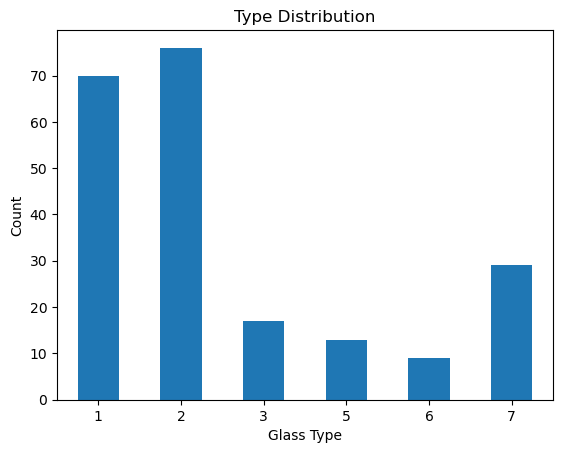

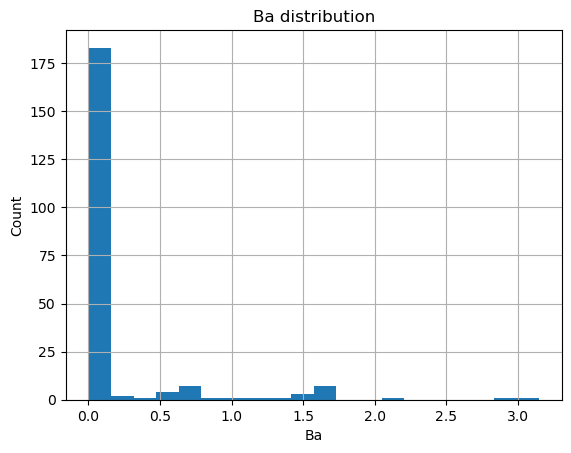

In [7]:
def load_data(path):
    df = pd.read_csv(path)
    return df

def inspect_df(df):
    print(df.head(5))
    print(df.info())
    print(df.describe())

def plot_type(df):
    df['Type'].value_counts().sort_index().plot(kind='bar')
    plt.xlabel('Glass Type')
    plt.ylabel('Count')
    plt.title('Type Distribution')
    plt.xticks(rotation=0)
    plt.show()

def plot_element(df, element):
    df[element].hist(bins=20)
    plt.xlabel(element)
    plt.ylabel('Count')
    plt.title(f'{element} distribution')
    plt.show()
    
df = load_data("../data/glass.csv")
inspect_df(df)
plot_type(df)
plot_element(df, 'Ba')

In [8]:
def split_data(df, test_size):
    y = df['Type']
    X = df.drop(columns=['Type'])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = test_size, stratify=y)
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = split_data(df, 0.2)
print(y_train.value_counts())

Type
2    61
1    56
7    23
3    14
5    10
6     7
Name: count, dtype: int64


# Logistic Regression Pipeline

In [9]:

def base_model(X_train):
    """Build base model first no lda or smote"""
    column_names = list(X_train.columns)
    preprocessor = ColumnTransformer(transformers=[
        ('nums', StandardScaler(), column_names)
    ])
    pipeline = Pipeline(steps=[
        ('preprocess', preprocessor),
        # multinomial LogisticRegression (sklearn's default for 3+ classes):
        # trains 6 separate scoring equations simultaneously (one per Type),
        # each with 5 coefficients + 1 intercept. NOT 6 separate boundaries
        # you could draw — softmax converts the 6 raw scores per point into
        # 6 competing probabilities that sum to 1, highest wins
        ('model', LogisticRegression())
    ])
    return pipeline

def model_smote(X_train):
    """model with SMOTE"""
    column_names = list(X_train.columns)
    preprocessor = ColumnTransformer(transformers=[
        ('nums', StandardScaler(), column_names)
    ])
    pipeline = ImbPipeline(steps=[
        # ImbPipeline required here, NOT plain Pipeline — SMOTE changes row
        # count (synthesizes new minority-class rows)
        ('preprocess', preprocessor),
        ('smote', SMOTE(random_state=42, k_neighbors =3)),
        ('model', LogisticRegression())
    ])
    return pipeline

def model_lda(X_train):
    """model with lda"""
    column_names = list(X_train.columns)
    preprocessor = ColumnTransformer(transformers=[
        ('nums', StandardScaler(), column_names)
    ])
    pipeline = Pipeline(steps=[
        ('preprocess', preprocessor),
        ('lda', LinearDiscriminantAnalysis()),
        ('model', LogisticRegression())
    ])
    return pipeline

def model_smote_lda(X_train):
    """model with SMOTE and lda"""
    column_names = list(X_train.columns)
    preprocessor = ColumnTransformer(transformers=[
        ('nums', StandardScaler(), column_names)
    ])
    pipeline = ImbPipeline(steps=[
        ('preprocess', preprocessor),
        ('smote', SMOTE(random_state=42, k_neighbors=3)),
        # SMOTE before LDA: LDA calculates each class's mean/spread to find
        # its separating axis — feeding it balanced data (post-SMOTE) gives
        # more stable class statistics than the raw, imbalanced version would
        ('lda', LinearDiscriminantAnalysis()),
        ('model', LogisticRegression())
    ])
    return pipeline

def hyperparameter_tunning_lda(pipeline, X_train, y_train):
    """tunnning for lda only"""
    params_grid = {
        'lda__n_components':[1, 2, 3, 4, 5],
    } 
    grid_search = GridSearchCV(pipeline, params_grid, cv = 5, scoring = 'recall_macro') #optimze recall becuase not capturing the right type/class will be costly
    grid_search.fit(X_train, y_train)
    return grid_search.best_estimator_


def matrix_calculation(y_test, pred):
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred, average='macro')
    recall = recall_score(y_test, pred, average='macro')
    f1 = f1_score(y_test, pred, average='macro')
    matrix = confusion_matrix(y_test, pred)
    return accuracy, precision, recall, f1, matrix


# Base model first
base_pipeline = base_model(X_train)
base_pipeline = base_pipeline.fit(X_train, y_train)
pred_1 = base_pipeline.predict(X_test)
accuracy_1, precision_1, recall_1, f1_1, matrix_1 = matrix_calculation(y_test, pred_1)
print(f"Base model:\nAccuracy: {accuracy_1}\nPrecision: {precision_1}\nRecall: {recall_1}\nF1: {f1_1}")
print("=" * 50)

# Base model + SMOTE
smote_pipeline = model_smote(X_train)
smote_pipeline = smote_pipeline.fit(X_train, y_train)
pred_2 = smote_pipeline.predict(X_test)
accuracy_2, precision_2, recall_2, f1_2, matrix_2 = matrix_calculation(y_test, pred_2)
print(f"Base + SMOTE:\nAccuracy: {accuracy_2}\nPrecision: {precision_2}\nRecall: {recall_2}\nF1: {f1_2}")
print("=" * 50)

# Base model + LDA
lda_pipeline = model_lda(X_train)
best_lda_pipeline = hyperparameter_tunning_lda(lda_pipeline, X_train, y_train)
pred_3 = best_lda_pipeline.predict(X_test)
accuracy_3, precision_3, recall_3, f1_3, matrix_3 = matrix_calculation(y_test, pred_3)
print(f"Base + LDA (n_components={best_lda_pipeline.named_steps['lda'].n_components}):\nAccuracy: {accuracy_3}\nPrecision: {precision_3}\nRecall: {recall_3}\nF1: {f1_3}")
print("=" * 50)

# Base model + SMOTE + LDA
all_pipeline = model_smote_lda(X_train)
best_all_pipeline = hyperparameter_tunning_lda(all_pipeline, X_train, y_train)
pred_4 = best_all_pipeline.predict(X_test)
accuracy_4, precision_4, recall_4, f1_4, matrix_4 = matrix_calculation(y_test, pred_4)
print(f"Base + SMOTE + LDA (n_components={best_all_pipeline.named_steps['lda'].n_components}):\nAccuracy: {accuracy_4}\nPrecision: {precision_4}\nRecall: {recall_4}\nF1: {f1_4}")
print("=" * 50)

recall_scores = {
    'base': recall_1,
    'smote': recall_2,
    'lda': recall_3,
    'smote_lda': recall_4
}

best_name = max(recall_scores, key=lambda name: recall_scores[name])
print(f"Best model: {best_name} (recall={recall_scores[best_name]})")

Base model:
Accuracy: 0.6511627906976745
Precision: 0.5925925925925926
Recall: 0.5357142857142857
F1: 0.5492859630790665
Base + SMOTE:
Accuracy: 0.6511627906976745
Precision: 0.6808608058608058
Recall: 0.7849206349206349
F1: 0.6963582311408398


c:\Users\Edward\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Base + LDA (n_components=5):
Accuracy: 0.6511627906976745
Precision: 0.6316526610644257
Recall: 0.5642857142857143
F1: 0.5795922036189
Base + SMOTE + LDA (n_components=5):
Accuracy: 0.5581395348837209
Precision: 0.5763888888888888
Recall: 0.6341269841269842
F1: 0.581048951048951
Best model: smote (recall=0.7849206349206349)
